<a href="https://colab.research.google.com/github/KieranRossetti/Stock-Risk-Clustering-Analysis/blob/main/Stock%20Risk%20Clustering%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance yahoofinancials --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import requests
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [3]:
#Load S&P 500 table
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}
response = requests.get(url, headers=headers)
response.raise_for_status()
sp500_tables = pd.read_html(response.text)
sp500_df = sp500_tables[0]

#Ticker symbols extraction
tickers = sp500_df["Symbol"].astype(str).str.replace('.','-', regex=False).tolist()
print("Number of tickers:",len(tickers))
print(sp500_df[['Symbol','Security','GICS Sector']])

/tmp/ipykernel_22824/1856398886.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500_tables = pd.read_html(response.text)


Number of tickers: 503
    Symbol             Security             GICS Sector
0      MMM                   3M             Industrials
1      AOS          A. O. Smith             Industrials
2      ABT  Abbott Laboratories             Health Care
3     ABBV               AbbVie             Health Care
4      ACN            Accenture  Information Technology
..     ...                  ...                     ...
498    XYL           Xylem Inc.             Industrials
499    YUM          Yum! Brands  Consumer Discretionary
500   ZBRA   Zebra Technologies  Information Technology
501    ZBH        Zimmer Biomet             Health Care
502    ZTS               Zoetis             Health Care

[503 rows x 3 columns]


In [4]:
start_date = "2022-01-01"
end_date = "2025-01-01"

#Download data for all tickers
data = yf.download(tickers=tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, threads=True)

#Inspection
print("Data type:", type(data))
print("Data shape:", data.shape)
print("Index (date) range:", data.index.min(), "to", data.index.max())

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['SNDK', 'Q']: YFPricesMissingError('possibly delisted; no price data found  (1d 2022-01-01 -> 2025-01-01) (Yahoo error = "Data doesn\'t exist for startDate = 1641013200, endDate = 1735707600")')


Data type: <class 'pandas.core.frame.DataFrame'>
Data shape: (753, 3018)
Index (date) range: 2022-01-03 00:00:00 to 2024-12-31 00:00:00


In [5]:
adj_close = data.xs('Adj Close', axis=1, level=1)

print("Adj Close shape before cleaning:", adj_close.shape)

#Remove columns with all NaNs
adj_close = adj_close.dropna(axis=1, how='all')

#Forward-fill and back-fill missing values (small gaps)
adj_close = adj_close.ffill().bfill()

#Remove non-positive prices
adj_close = adj_close[adj_close > 0]

#Drop any rows that are now all NaN
adj_close = adj_close.dropna(axis=0, how='all')

print("Adj Close shape after cleaning:", adj_close.shape)
print("Remaining tickers:", len(adj_close.columns))

Adj Close shape before cleaning: (753, 503)
Adj Close shape after cleaning: (753, 501)
Remaining tickers: 501


In [6]:
#Daily percentage returns for each stock
daily_returns = adj_close.pct_change().dropna(how='all')

print('Daily returns shape:', daily_returns.shape)
daily_returns.head()

Daily returns shape: (752, 501)


Ticker,PTC,HSIC,SWKS,HON,ODFL,WTW,MOS,ZBRA,WST,CHTR,...,HBAN,BXP,MSFT,SYY,FISV,CL,STE,INVH,CVS,NOC
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.003090,0.023893,0.009200,0.010639,0.024858,0.013159,0.007714,0.006337,-0.037944,-0.010516,...,0.037975,0.033267,-0.017147,0.024446,0.012823,0.003310,0.010677,0.003558,0.001248,0.029725
2022-01-05,-0.034829,-0.003658,-0.019659,0.009856,-0.035777,-0.006955,-0.037037,-0.050068,-0.058345,-0.024830,...,0.001220,-0.013475,-0.038388,-0.008408,-0.005872,0.004124,-0.025494,-0.027476,0.014575,-0.005038
2022-01-06,-0.010057,-0.014306,0.000380,-0.001137,-0.000263,-0.011265,0.010513,-0.005410,0.009332,0.011347,...,0.037150,0.020775,-0.007902,-0.000752,0.007198,-0.006571,-0.001884,-0.003190,-0.030432,0.005772
2022-01-07,-0.017586,0.013999,-0.024851,0.023385,-0.028025,-0.011863,0.019538,-0.043771,-0.042355,-0.033958,...,0.011157,0.006651,0.000510,0.009916,-0.002840,-0.002599,-0.015307,-0.018971,0.015596,0.007929
2022-01-10,-0.004692,0.002533,-0.000778,-0.010614,-0.007306,0.004578,-0.003484,0.008571,0.005378,-0.008288,...,-0.011034,-0.004139,0.000732,-0.014293,-0.009924,-0.008645,-0.014011,-0.006524,0.008350,0.004520


In [7]:
#Download spy as market proxy
spy = yf.download('SPY',start=start_date, end=end_date, auto_adjust=False)
spy_adj = spy['Adj Close']
spy_returns = spy_adj.pct_change().dropna()

#Align stock returns with spy dates
common_idx = daily_returns.index.intersection(spy_returns.index)
daily_returns = daily_returns.loc[common_idx]
spy_returns = spy_returns.loc[common_idx]

[*********************100%***********************]  1 of 1 completed


In [8]:
#Beta per ticker

betas = {}

market_std = float(spy_returns.std())

for t in daily_returns.columns:
  r_i = daily_returns[t].dropna()
  aligned = pd.concat([r_i, spy_returns],
                      axis=1, join='inner').dropna()
  if aligned.shape[0] <10:
    continue
  stock_ret = aligned.iloc[:,0]
  market_ret = aligned.iloc[:,1]
  corr = stock_ret.corr(market_ret)
  stock_std = float(stock_ret.std())
  beta = corr * (stock_std / market_std)
  betas[t] = beta

beta_series = pd.Series(betas, name='Beta')
print('Computed betas for', beta_series.shape[0], 'tickers')
beta_series.head()

/tmp/ipykernel_22824/1800829237.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  market_std = float(spy_returns.std())


Computed betas for 501 tickers


,Beta
PTC,1.123427
HSIC,0.606834
SWKS,1.507008
HON,0.771190
ODFL,1.242313


In [9]:
#Annual volatility per ticker

#Standard deviation of daily returns * sqrt(252)
annual_vol = daily_returns.std() * np.sqrt(252)
annual_vol.name = 'AnnualVolatility'

print('Annual volatility calculated for', annual_vol.shape[0], 'tickers')
annual_vol.head()

Annual volatility calculated for 501 tickers


,AnnualVolatility
Ticker,
PTC,0.284920
HSIC,0.249920
SWKS,0.370608
HON,0.206504
ODFL,0.363113


In [10]:
#Summary table

#Average daily return over the period
avg_daily_ret = daily_returns.mean()
avg_daily_ret.name = 'AvgDailyReturn'

metrics_df = pd.concat([avg_daily_ret, beta_series, annual_vol], axis=1)

metrics_df = metrics_df.dropna()
print('Metrics Table shape:', metrics_df.shape)
metrics_df.head()

Metrics Table shape: (501, 3)


,AvgDailyReturn,Beta,AnnualVolatility
PTC,0.000694,1.123427,0.284920
HSIC,-0.000026,0.606834,0.249920
SWKS,-0.000408,1.507008,0.370608
HON,0.000287,0.771190,0.206504
ODFL,0.000305,1.242313,0.363113


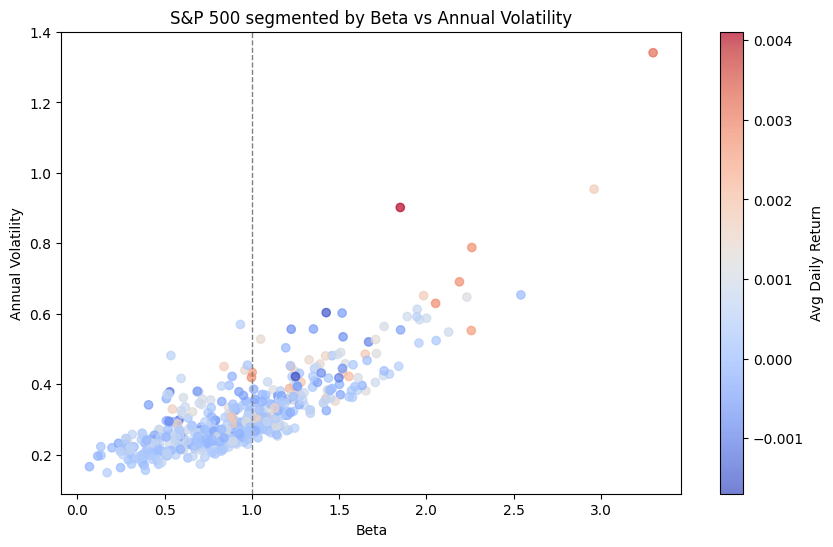

In [11]:
#Beta vs Annual Volatility scatterplot

metrics_df = metrics_df.dropna(subset=['AvgDailyReturn','Beta','AnnualVolatility'])

plt.figure(figsize=(10,6))
scatter = plt.scatter(metrics_df['Beta'],metrics_df['AnnualVolatility'],c=metrics_df['AvgDailyReturn'],cmap='coolwarm',alpha=0.7)
plt.colorbar(scatter, label='Avg Daily Return')
plt.axvline(1.0, color='grey', linestyle='--', linewidth=1) #market beta
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('S&P 500 segmented by Beta vs Annual Volatility')
plt.show()

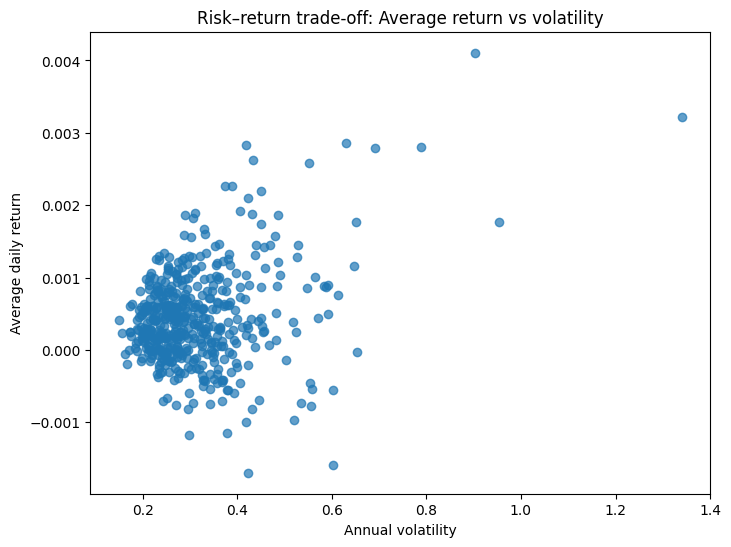

In [12]:
#Return vs Volatility scatterplot
plt.figure(figsize=(8,6))
plt.scatter(metrics_df['AnnualVolatility'],metrics_df['AvgDailyReturn'],alpha=0.7)
plt.xlabel('Annual volatility')
plt.ylabel('Average daily return')
plt.title('Risk–return trade‑off: Average return vs volatility')
plt.show()

In [13]:
df_agg = metrics_df.copy()
df_agg = df_agg[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].copy()
print(df_agg.shape)
df_agg.head()

(501, 3)


,AvgDailyReturn,Beta,AnnualVolatility
PTC,0.000694,1.123427,0.284920
HSIC,-0.000026,0.606834,0.249920
SWKS,-0.000408,1.507008,0.370608
HON,0.000287,0.771190,0.206504
ODFL,0.000305,1.242313,0.363113


In [14]:
#Standardising the variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_agg)

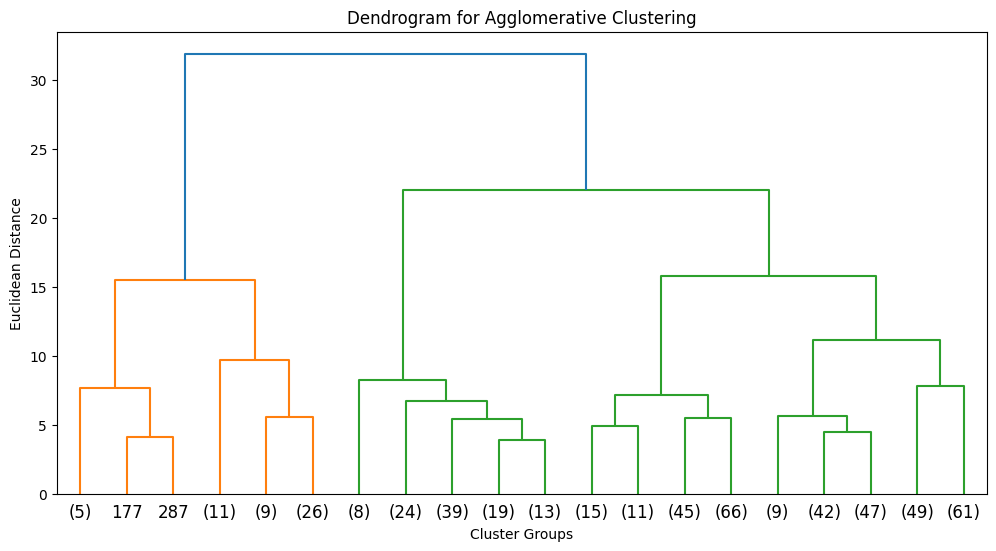

In [15]:
#Building a Dendogram
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=20)
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Cluster Groups')
plt.ylabel('Euclidean Distance')
plt.show()

In [16]:
#Calculating Silhouette scores for different values of N
for n in range(2, 7):
    model = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Number of clusters = {n}, Silhouette Score = {score:.4f}")

Number of clusters = 2, Silhouette Score = 0.5185
Number of clusters = 3, Silhouette Score = 0.3196
Number of clusters = 4, Silhouette Score = 0.2486
Number of clusters = 5, Silhouette Score = 0.2607
Number of clusters = 6, Silhouette Score = 0.2424


In [17]:
#Select final number of clusters
best_n = 2

In [18]:
#Fitting the agglomerative clustering model
agg_model = AgglomerativeClustering(n_clusters=best_n, linkage='ward')
agg_labels = agg_model.fit_predict(X_scaled)

df_agg_result = df_agg.copy()
df_agg_result['AgglomerativeCluster'] = agg_labels

df_agg_result.head()

,AvgDailyReturn,Beta,AnnualVolatility,AgglomerativeCluster
PTC,0.000694,1.123427,0.284920,0
HSIC,-0.000026,0.606834,0.249920,0
SWKS,-0.000408,1.507008,0.370608,0
HON,0.000287,0.771190,0.206504,0
ODFL,0.000305,1.242313,0.363113,0


In [19]:
#Cluster summary table
agg_summary = df_agg_result.groupby('AgglomerativeCluster')[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].mean()
agg_summary['Count'] = df_agg_result.groupby('AgglomerativeCluster').size()

agg_summary

,AvgDailyReturn,Beta,AnnualVolatility,Count
AgglomerativeCluster,,,,
0,0.000313,0.851750,0.288818,448
1,0.001517,1.653312,0.518915,53


In [20]:
#Sample stocks from each cluster
for cluster_num in sorted(df_agg_result['AgglomerativeCluster'].unique()):
    print(f"\nCluster {cluster_num}")
    print(df_agg_result[df_agg_result['AgglomerativeCluster'] == cluster_num].index.tolist()[:15])


Cluster 0
['PTC', 'HSIC', 'SWKS', 'HON', 'ODFL', 'WTW', 'MOS', 'ZBRA', 'WST', 'CHTR', 'WDAY', 'SYK', 'GS', 'LULU', 'ERIE']

Cluster 1
['FSLR', 'TTD', 'ARES', 'CEG', 'EQT', 'RL', 'PANW', 'UAL', 'PHM', 'APO', 'STLD', 'TPL', 'TPR', 'KKR', 'TSLA']


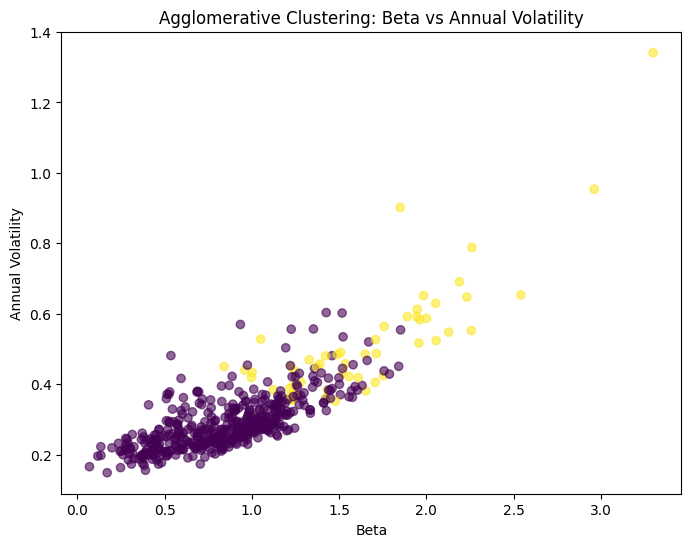

In [21]:
#Beta VS AnnualVolatility Graph
plt.figure(figsize=(8, 6))
plt.scatter(df_agg_result['Beta'], df_agg_result['AnnualVolatility'], c=df_agg_result['AgglomerativeCluster'], alpha=0.6)
plt.title('Agglomerative Clustering: Beta vs Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.show()

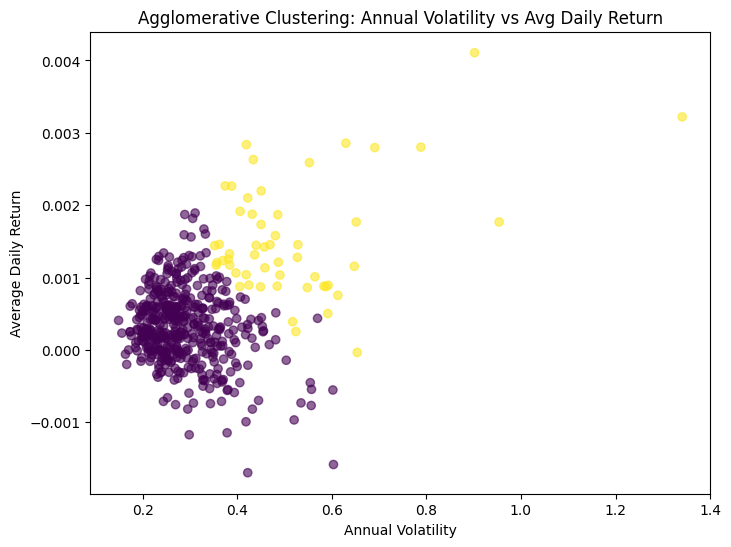

In [22]:
#AnnualVolatility VS AvgDailyReturn Graph
plt.figure(figsize=(8, 6))
plt.scatter(df_agg_result['AnnualVolatility'], df_agg_result['AvgDailyReturn'], c=df_agg_result['AgglomerativeCluster'], alpha=0.6)
plt.title('Agglomerative Clustering: Annual Volatility vs Avg Daily Return')
plt.xlabel('Annual Volatility')
plt.ylabel('Average Daily Return')
plt.show()

In [23]:
df_kmeans = metrics_df.copy()
df_kmeans = df_kmeans[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].copy()
print(df_kmeans.shape)
df_kmeans.head()

(501, 3)


,AvgDailyReturn,Beta,AnnualVolatility
PTC,0.000694,1.123427,0.284920
HSIC,-0.000026,0.606834,0.249920
SWKS,-0.000408,1.507008,0.370608
HON,0.000287,0.771190,0.206504
ODFL,0.000305,1.242313,0.363113


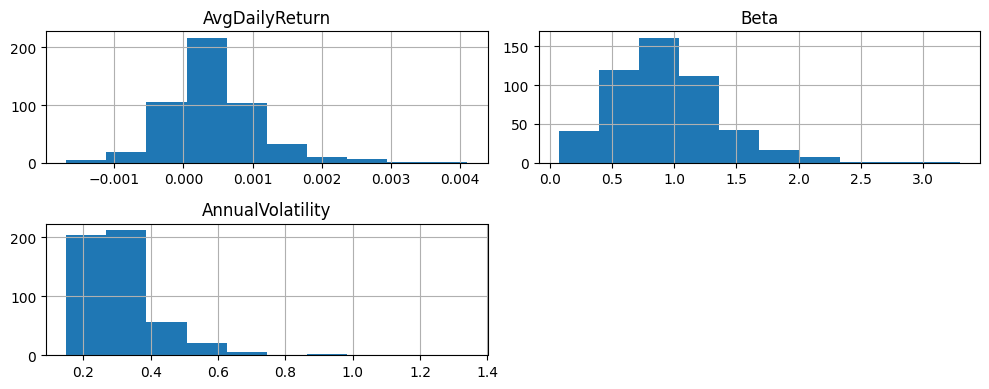

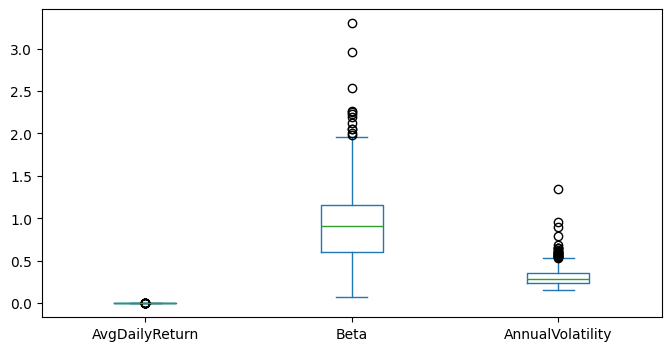

In [24]:
#Checking for skewness and outliers
df_kmeans[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].hist(figsize=(10, 4))
plt.tight_layout()
plt.show()

df_kmeans[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].plot(kind='box', figsize=(8, 4))
plt.show()

In [25]:
#Reducing the influence of extreme values
for col in ['AvgDailyReturn', 'Beta', 'AnnualVolatility']:
    lower = df_kmeans[col].quantile(0.01)
    upper = df_kmeans[col].quantile(0.99)
    df_kmeans[col] = df_kmeans[col].clip(lower, upper)

In [26]:
#Standardising the variables
X_scaled = scaler.fit_transform(df_kmeans)

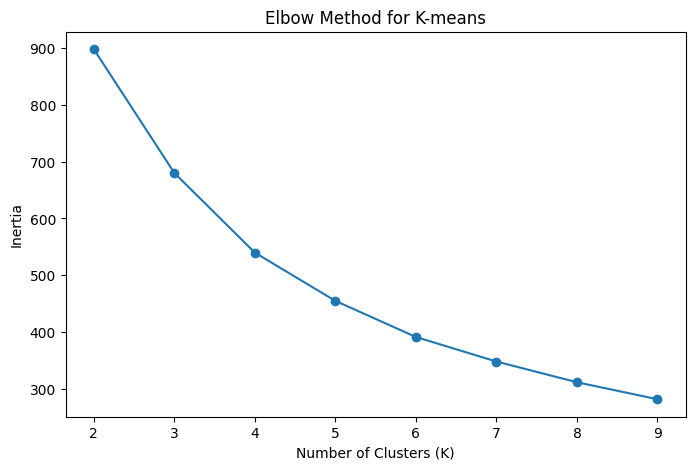

In [27]:
#Using the elbow method to choose K
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 10), inertia, marker='o')
plt.title('Elbow Method for K-means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

In [28]:
#Calculating Silhouette scores for different values of K
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4544
K = 3, Silhouette Score = 0.3356
K = 4, Silhouette Score = 0.3018
K = 5, Silhouette Score = 0.2973
K = 6, Silhouette Score = 0.3007
K = 7, Silhouette Score = 0.2955
K = 8, Silhouette Score = 0.2973
K = 9, Silhouette Score = 0.2907


In [29]:
#Choosing the final number of clusters
best_k = 2

In [30]:
#Fitting the final K-means model
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

df_kmeans_result = df_kmeans.copy()
df_kmeans_result['KMeansCluster'] = kmeans_labels

df_kmeans_result.head()

,AvgDailyReturn,Beta,AnnualVolatility,KMeansCluster
PTC,0.000694,1.123427,0.284920,0
HSIC,-0.000026,0.606834,0.249920,0
SWKS,-0.000408,1.507008,0.370608,1
HON,0.000287,0.771190,0.206504,0
ODFL,0.000305,1.242313,0.363113,1


In [31]:
#Cluster profile table
kmeans_summary = df_kmeans_result.groupby('KMeansCluster')[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].mean()
kmeans_summary['Count'] = df_kmeans_result.groupby('KMeansCluster').size()

kmeans_summary

,AvgDailyReturn,Beta,AnnualVolatility,Count
KMeansCluster,,,,
0,0.000339,0.772419,0.269929,391
1,0.000800,1.503634,0.454592,110


In [32]:
#Sample stocks from each cluster
for cluster_num in sorted(df_kmeans_result['KMeansCluster'].unique()):
    print(f"\nCluster {cluster_num}")
    print(df_kmeans_result[df_kmeans_result['KMeansCluster'] == cluster_num].index.tolist()[:15])


Cluster 0
['PTC', 'HSIC', 'HON', 'WTW', 'MOS', 'WST', 'CHTR', 'SYK', 'GS', 'ERIE', 'CTRA', 'FOX', 'VRTX', 'AXP', 'GIS']

Cluster 1
['SWKS', 'ODFL', 'ZBRA', 'WDAY', 'LULU', 'IVZ', 'FSLR', 'TTD', 'ARES', 'CEG', 'EQT', 'RL', 'PANW', 'UAL', 'PHM']


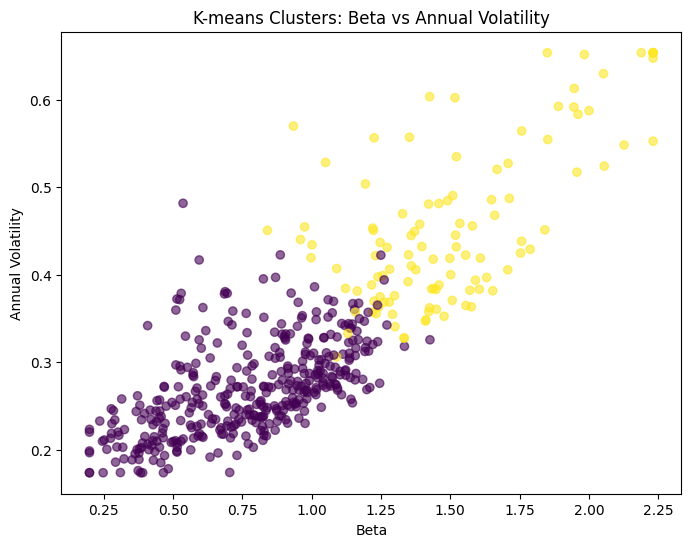

In [33]:
#Beta VS AnnualVolatility Graph
plt.figure(figsize=(8, 6))
plt.scatter(df_kmeans_result['Beta'], df_kmeans_result['AnnualVolatility'], c=df_kmeans_result['KMeansCluster'], alpha=0.6)
plt.title('K-means Clusters: Beta vs Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.show()

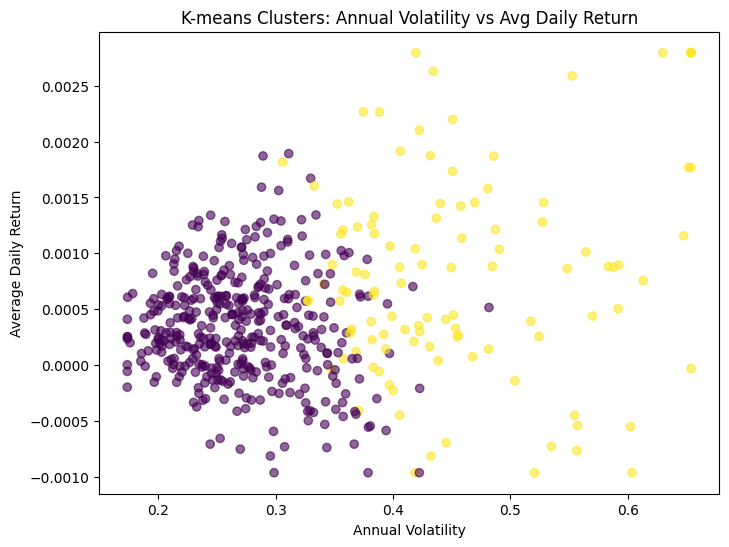

In [34]:
#AnnualVolatility VS AvgDailyReturn Graph
plt.figure(figsize=(8, 6))
plt.scatter(df_kmeans_result['AnnualVolatility'], df_kmeans_result['AvgDailyReturn'], c=df_kmeans_result['KMeansCluster'], alpha=0.6)
plt.title('K-means Clusters: Annual Volatility vs Avg Daily Return')
plt.xlabel('Annual Volatility')
plt.ylabel('Average Daily Return')
plt.show()

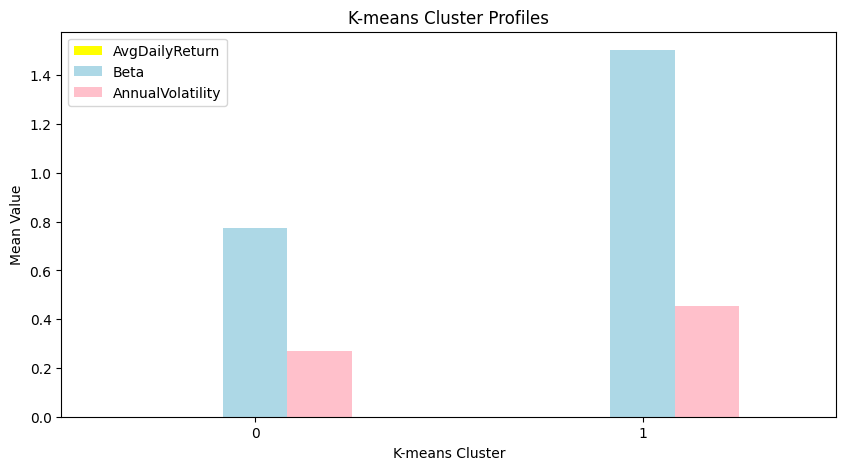

In [35]:
#Cluster profile bar graph
kmeans_summary[['AvgDailyReturn', 'Beta', 'AnnualVolatility']].plot(kind='bar', figsize=(10, 5), color=['yellow', 'lightblue', 'pink'])
plt.title('K-means Cluster Profiles')
plt.xlabel('K-means Cluster')
plt.ylabel('Mean Value')
plt.xticks(rotation=0)

plt.show()